In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import tqdm
from uncertainty_explainer.uq_explainer import UncertaintyExplanationPipeline

In [49]:
X, y = make_regression(
n_samples=200,
n_features=5,
noise=0.1,
)

In [50]:
X_train = X[:120]
y_train = y[:120]

X_calib = X[120:160]
y_calib = y[120:160]

X_test = X[160:]

# model = RandomForestRegressor()

# pipeline = (
#     UncertaintyExplanationPipeline(model)
# )



In [51]:
X_test[:, 0]

array([-1.23392088,  0.5053054 ,  1.91154636,  0.89075792,  0.31821926,
        0.07207273, -0.3110825 ,  0.6110624 ,  1.22893159, -1.16574626,
        0.57632192, -0.31897317, -1.22621024, -0.23532405,  1.16140768,
        0.97076886,  0.43089134, -0.79113697, -0.07355527,  1.94785469,
        1.01252972, -0.16929497, -1.17314384, -0.94471144,  1.33492956,
       -0.88400081,  0.63481799, -0.12512774,  0.37355536, -0.13950186,
       -0.17318736, -2.33661273,  1.34072369,  0.68820675,  1.48711341,
        0.83406526,  0.98444297, -0.97812081, -0.20352851, -0.31023606])

## Test

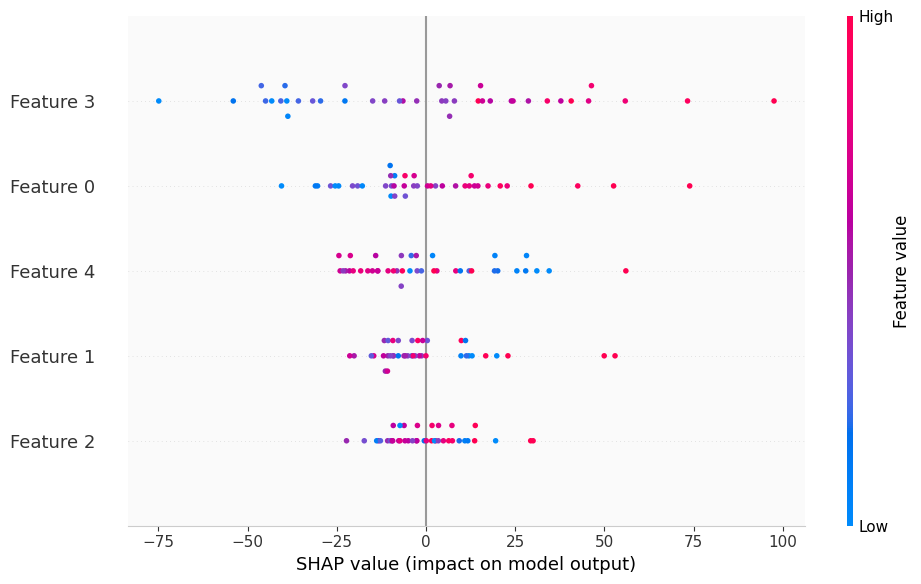

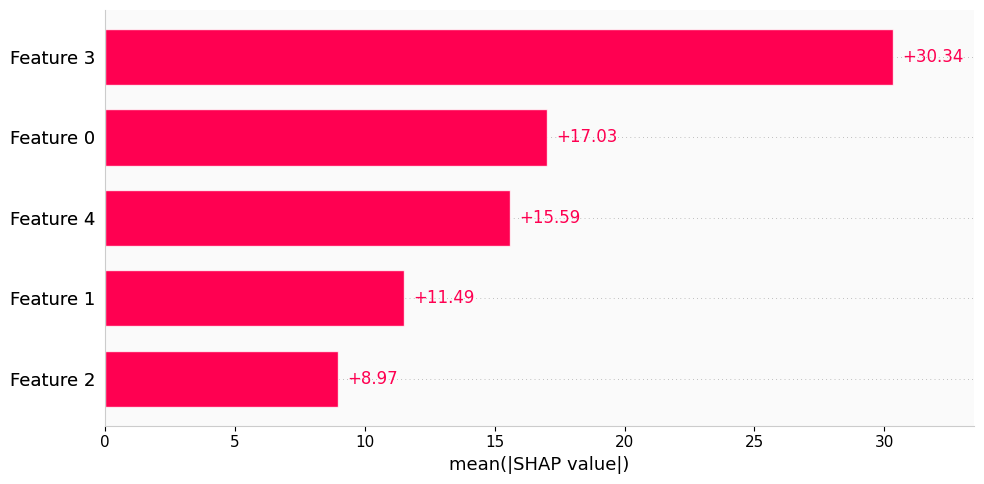

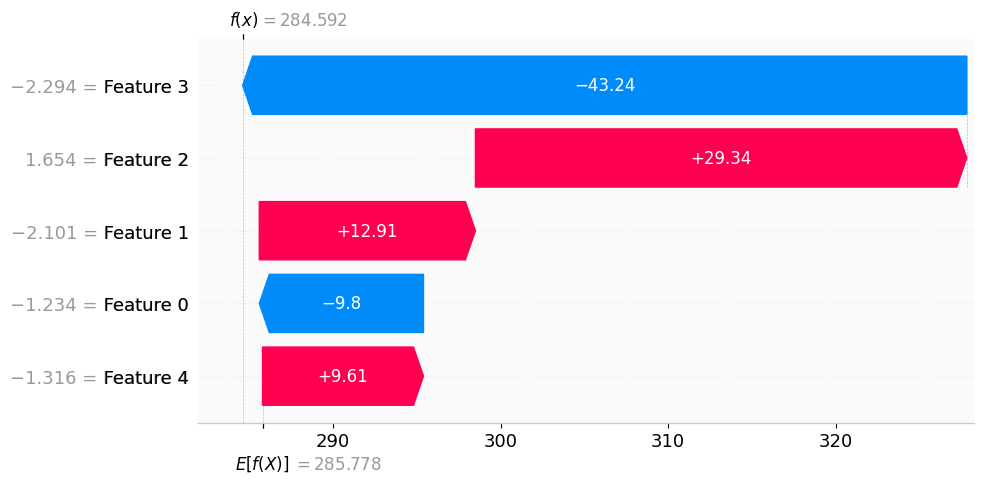

In [52]:
from sklearn.ensemble import RandomForestRegressor
from uncertainty_explainer.uq_explainer import (
    UncertaintyExplanationPipeline
)

pipeline = UncertaintyExplanationPipeline(
    RandomForestRegressor()
)

pipeline.fit(
    X_train,
    y_train,
    X_calib,
    y_calib,
)

result = pipeline.explain_uncertainty(
    X_test
)

In [30]:
result['interval_width']

array([150.0463818 , 168.89573758, 193.33268318, 164.24877144,
       159.23588789, 135.18137883, 191.85901941, 156.34618531,
       177.00398513, 166.35077493, 135.79357218, 176.96243729,
       166.91568647, 207.83964826, 186.50476484, 183.75719818,
       188.00517359, 184.85758024, 158.38486998, 188.61971774,
       152.18963503, 132.87710851, 143.56130328, 190.61960282,
       166.87320769, 157.55731061, 107.13798998, 162.54780546,
       187.89570651, 182.11231053, 216.45333794, 141.31785466,
       159.30135177, 184.42264121, 144.46324693, 155.81718563,
       158.82034484, 210.71216404, 139.12638974, 213.92275797])

## Exemplo 2

In [31]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from crepes import WrapRegressor
dataset = fetch_openml(name="house_sales", version=3, parser="auto")

X = dataset.data.values.astype(float)
y = dataset.target.values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)
X_prop_train, X_cal, y_prop_train, y_cal = train_test_split(X_train, y_train,
                                                            test_size=0.25)

In [32]:
pipeline = UncertaintyExplanationPipeline(
    RandomForestRegressor()
)

pipeline.fit(
    X_prop_train,
    y_prop_train,
    X_cal,
    y_cal,
)

# result = pipeline.explain_uncertainty(
#     X_test
# )

In [33]:
X_test

array([[3.000e+00, 3.000e+00, 1.530e+03, ..., 2.014e+03, 1.000e+01,
        3.100e+01],
       [3.000e+00, 1.750e+00, 2.320e+03, ..., 2.014e+03, 8.000e+00,
        2.600e+01],
       [4.000e+00, 2.750e+00, 2.160e+03, ..., 2.014e+03, 1.200e+01,
        1.700e+01],
       ...,
       [4.000e+00, 2.750e+00, 2.640e+03, ..., 2.014e+03, 9.000e+00,
        1.200e+01],
       [4.000e+00, 2.500e+00, 2.640e+03, ..., 2.014e+03, 9.000e+00,
        1.900e+01],
       [3.000e+00, 3.000e+00, 1.420e+03, ..., 2.015e+03, 4.000e+00,
        1.000e+00]], shape=(1081, 21))

In [34]:
result = pipeline.explain_uncertainty(
    X_test,
    algorithm="permutation"
)

PermutationExplainer explainer:  26%|██▌       | 278/1081 [05:33<16:39,  1.24s/it]


KeyboardInterrupt: 

In [ ]:
X_test

array([[4.000e+00, 3.500e+00, 1.800e+03, ..., 2.014e+03, 7.000e+00,
        1.000e+01],
       [2.000e+00, 1.000e+00, 1.060e+03, ..., 2.014e+03, 8.000e+00,
        4.000e+00],
       [4.000e+00, 2.500e+00, 3.040e+03, ..., 2.015e+03, 4.000e+00,
        8.000e+00],
       ...,
       [4.000e+00, 3.500e+00, 2.490e+03, ..., 2.015e+03, 5.000e+00,
        1.300e+01],
       [3.000e+00, 3.000e+00, 4.020e+03, ..., 2.015e+03, 2.000e+00,
        1.000e+01],
       [3.000e+00, 2.250e+00, 1.450e+03, ..., 2.014e+03, 9.000e+00,
        3.000e+00]], shape=(1081, 21))